In [ ]:
"""
============================================================
  Diabetes Prediction - Classification Models
============================================================
  Description : Predicting diabetes using multiple ML models
  Dataset     : Diabetes Prediction Dataset (CSV)
  Models Used : KNN, Naive Bayes, Decision Tree, SVM
  Author      : Lama Osama Lubbad
  Date        : 2024
============================================================
"""

'\n============================================================\n  Diabetes Prediction - Classification Models\n============================================================\n  Description : Predicting diabetes using multiple ML models\n  Dataset     : Diabetes Prediction Dataset (CSV)\n  Models Used : KNN, Naive Bayes, Decision Tree, SVM\n  Author      : Lama Osama Lubbad\n  Date        : 2024\n============================================================\n'

In [ ]:
# ============================================================
# 1. Import libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm, metrics
from sklearn.svm import LinearSVC

import subprocess, sys
try:
    import kagglehub
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kagglehub"])
    import kagglehub

In [ ]:
# ============================================================
# 2. Load data
# ============================================================
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")
ds = pd.read_csv(os.path.join(path, "diabetes_prediction_dataset.csv"))

Using Colab cache for faster access to the 'diabetes-prediction-dataset' dataset.


In [ ]:
# ============================================================
# 3. Encode Categorical Columns
# ============================================================
# Encode gender column : Female=1, Male=0
ds['gender'] = ds['gender'].map({'Female': 1, 'Male': 0})

# Encode smoking history column into numeric values
ds['smoking_history'] = ds['smoking_history'].map({
    'never'       : 0,
    'No Info'     : 1,
    'current'     : 2,
    'former'      : 3,
    'ever'        : 4,
    'not current' : 5
})

print("\n>> Categorical columns encoded successfully")
ds.info()


>> Categorical columns encoded successfully
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               99982 non-null   float64
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  int64  
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 6.9 MB


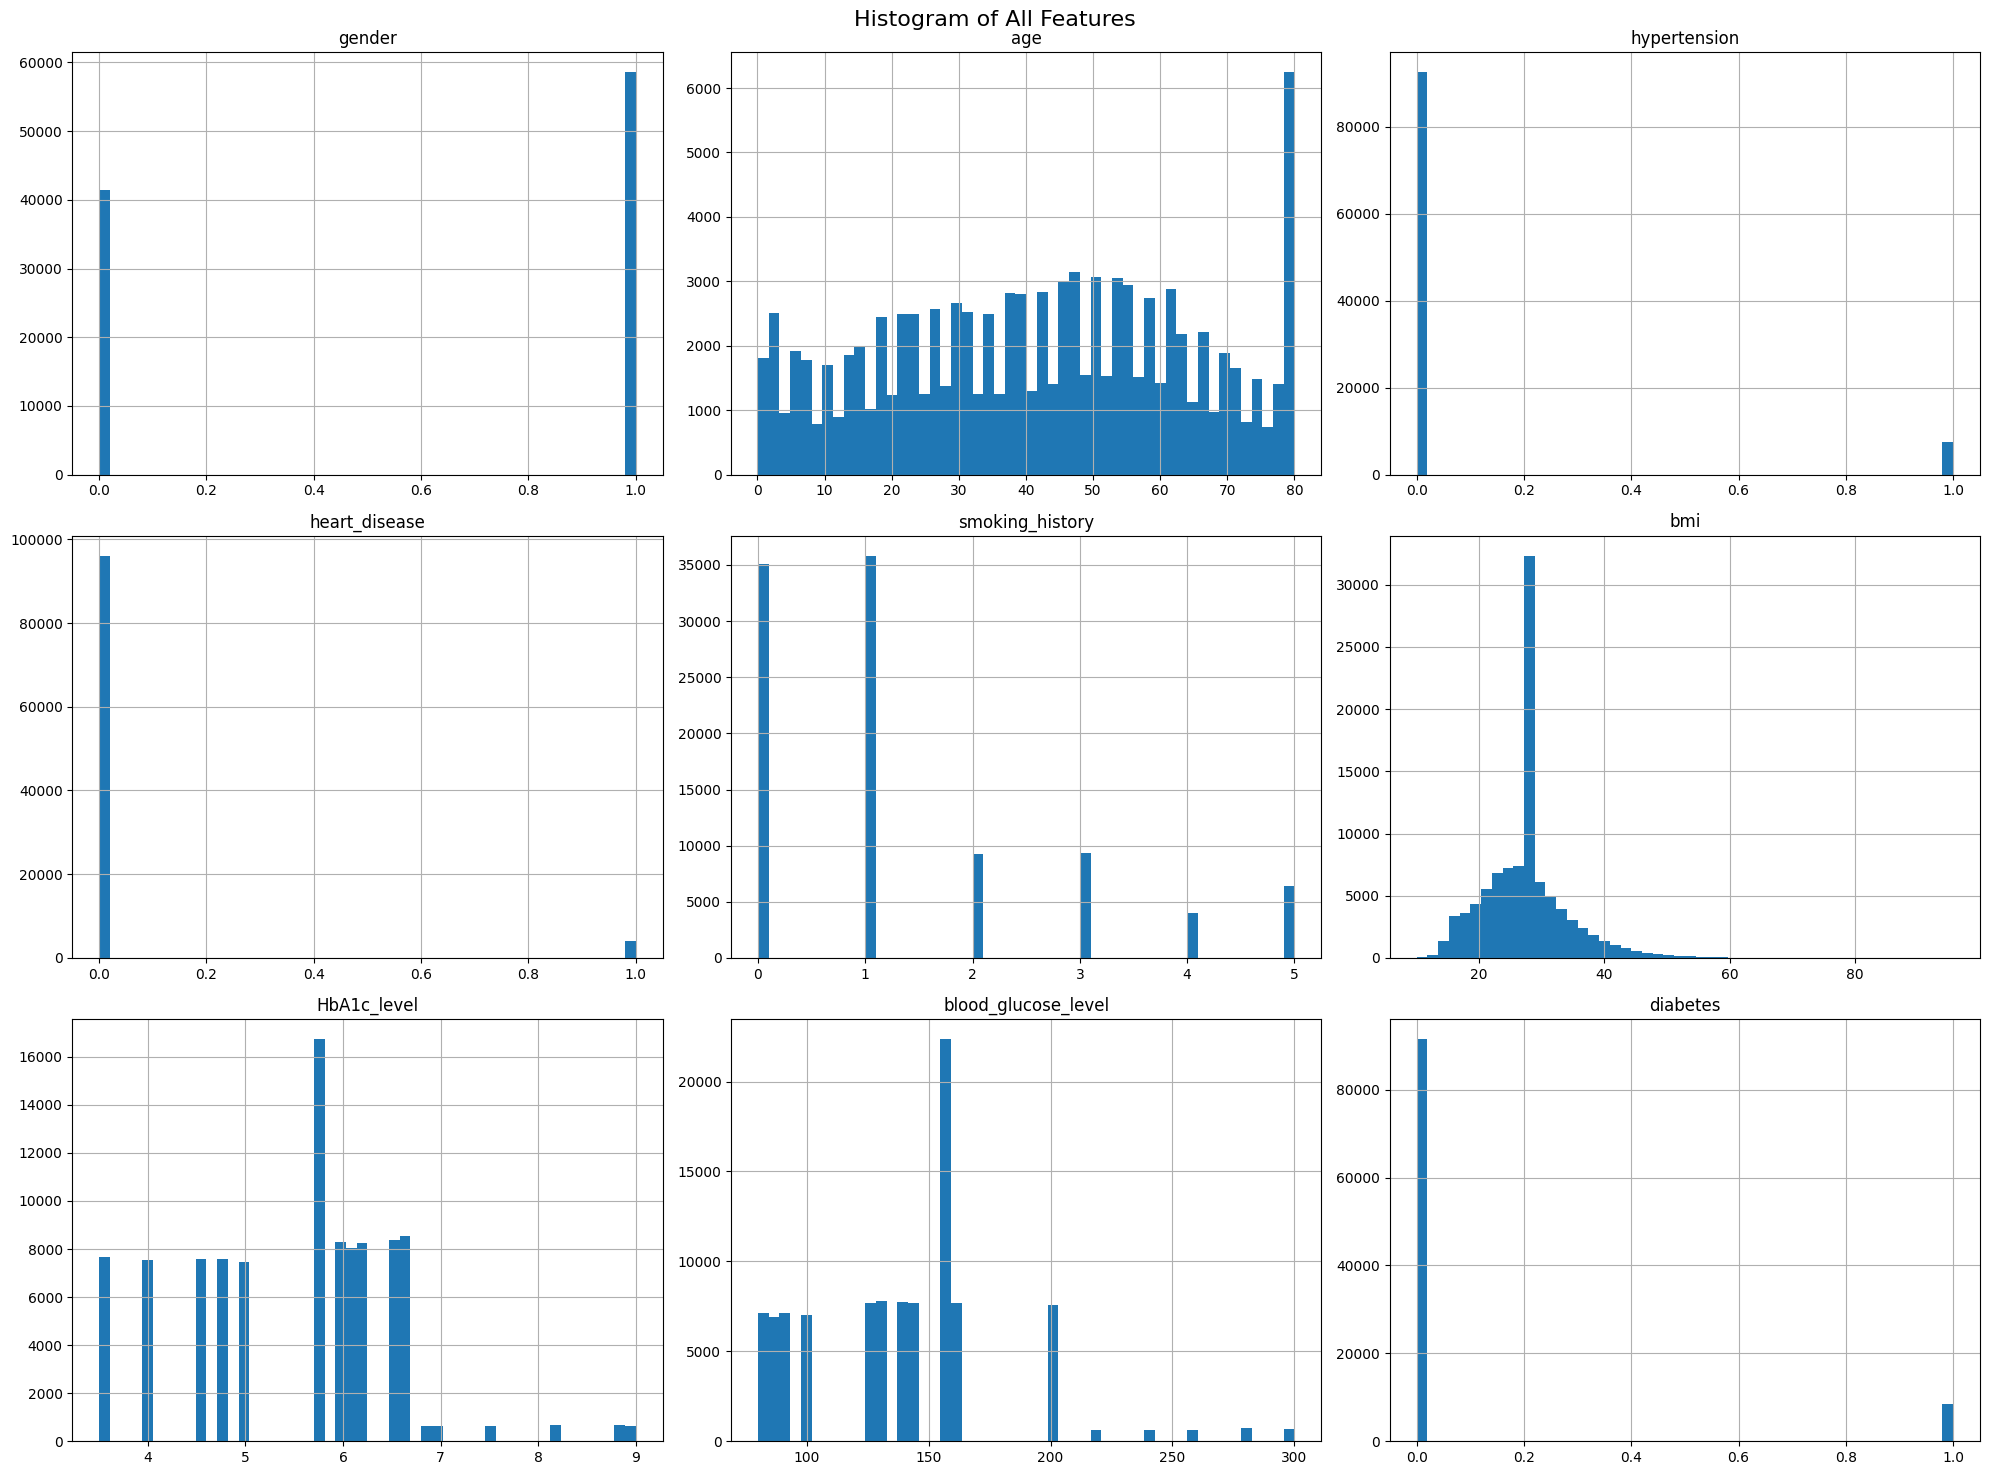

In [ ]:
# ============================================================
# 4. Exploratory Data Analysis (EDA)
# ============================================================

# Histogram for all columns to understand data distribution
ds.hist(bins=50, figsize=(20, 15))
plt.suptitle("Histogram of All Features", fontsize=16)
plt.tight_layout()
plt.show()

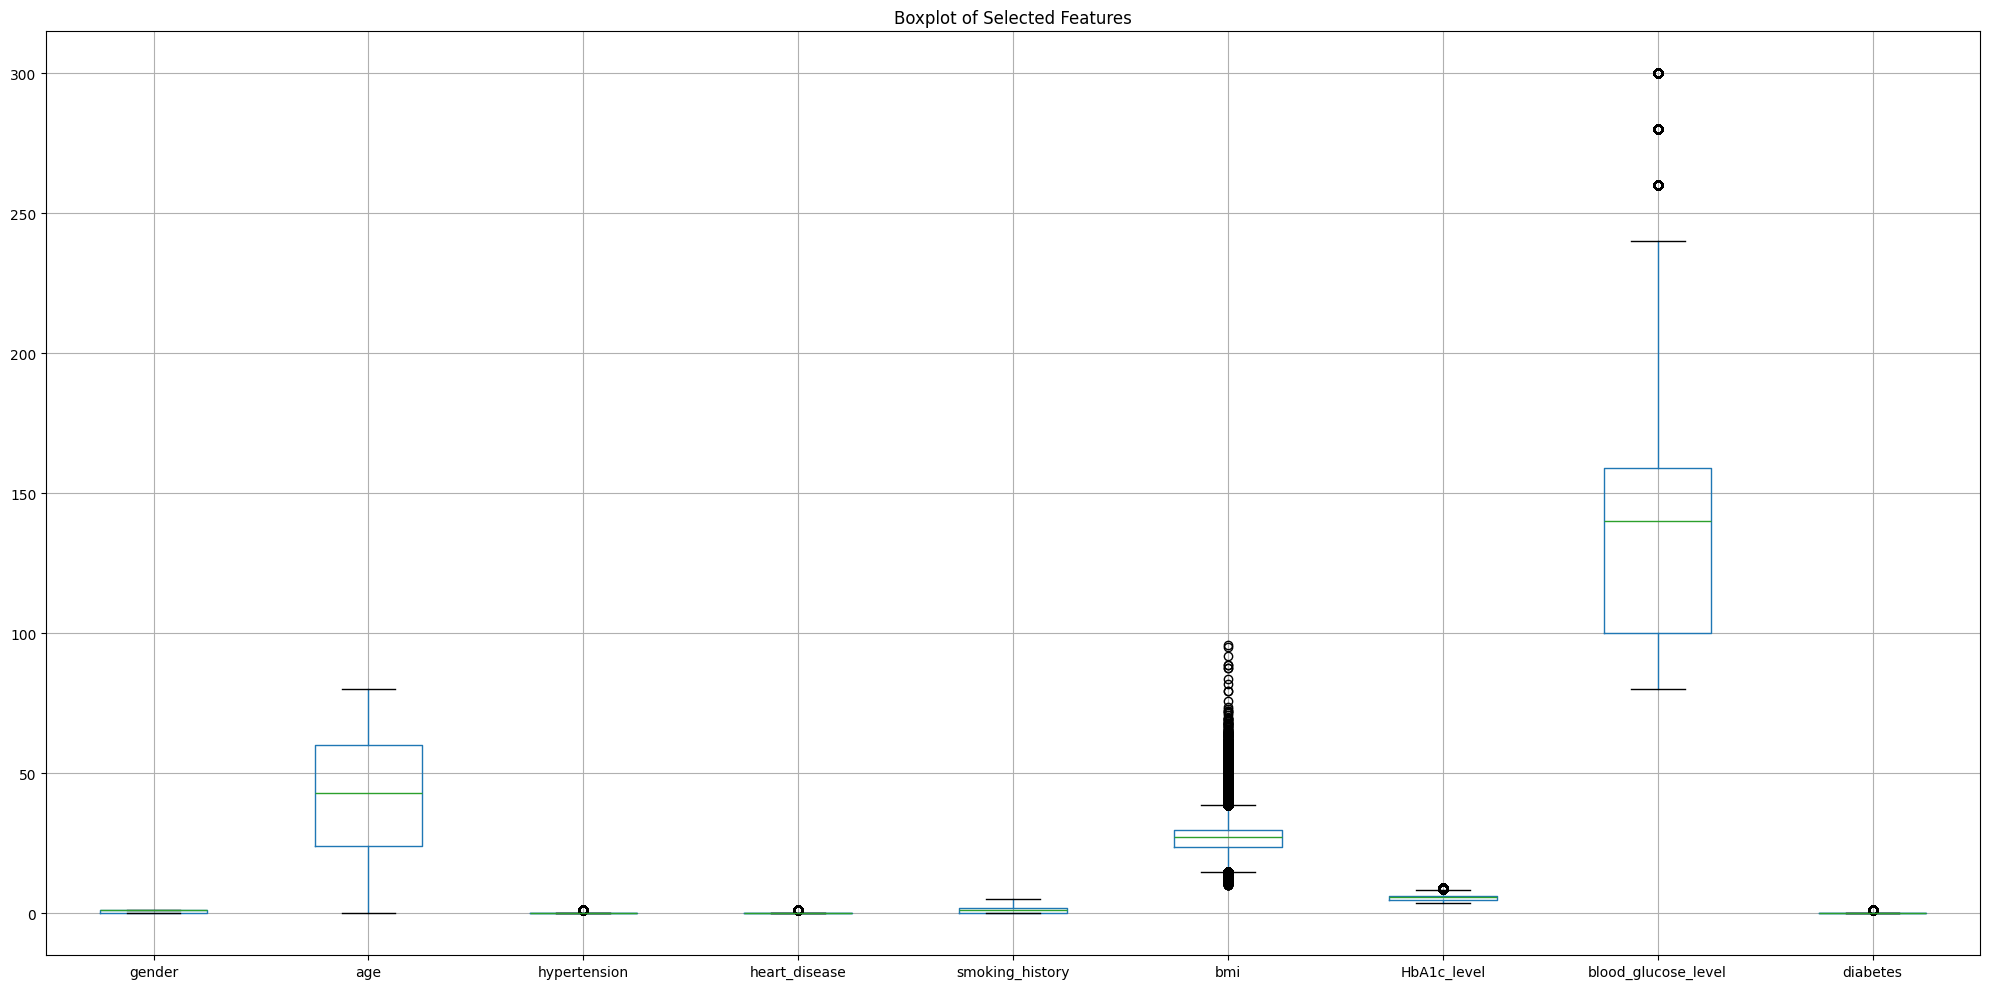

In [ ]:
# Boxplot to detect outliers in key features
atts = ['gender', 'age', 'hypertension', 'heart_disease',
        'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
plt.figure(figsize=(20, 10))
ds[atts].boxplot()
plt.title("Boxplot of Selected Features")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 5. Handle Outliers
# ============================================================

# Check for invalid age values (age cannot exceed 120)
print("\n>> Rows with invalid age (> 120):")
print(ds[ds['age'] > 120])

# Fix the outlier row automatically
outlier_idx = ds[ds['age'] > 120].index
if len(outlier_idx) > 0:
    ds.loc[outlier_idx[0], 'age'] = 44   # Replace with the correct value
    print(f">> Fixed age outlier at row {outlier_idx[0]} -> set to 44")

# Verify the fix
print(">> Remaining rows with age > 120:", len(ds[ds['age'] > 120]))


>> Rows with invalid age (> 120):
Empty DataFrame
Columns: [gender, age, hypertension, heart_disease, smoking_history, bmi, HbA1c_level, blood_glucose_level, diabetes]
Index: []
>> Remaining rows with age > 120: 0


In [ ]:
ds.shape

(100000, 9)

In [ ]:
# ============================================================
# 6. Remove Duplicate Rows
# ============================================================
print(f"\n>> Duplicate rows found : {ds.duplicated().sum()}")
ds.drop_duplicates(inplace=True)
print(f">> Shape after removing duplicates : {ds.shape}")


>> Duplicate rows found : 3854
>> Shape after removing duplicates : (96146, 9)


In [ ]:
# ============================================================
# 7. Handle Missing Values
# ============================================================
print("\n>> Missing values BEFORE handling:")
print(pd.DataFrame({'missing': ds.isnull().sum()}))


>> Missing values BEFORE handling:
                     missing
gender                    18
age                        0
hypertension               0
heart_disease              0
smoking_history            0
bmi                        0
HbA1c_level                0
blood_glucose_level        0
diabetes                   0


In [ ]:
# Fill missing numeric values with column mean
ds['heart_disease'] = ds['heart_disease'].fillna(ds['heart_disease'].mean())
ds['HbA1c_level']   = ds['HbA1c_level'].fillna(ds['HbA1c_level'].mean())

# Drop any remaining rows with missing values
ds.dropna(inplace=True)

print("\n>> Missing values AFTER handling:")
print(pd.DataFrame({'missing': ds.isnull().sum()}))


>> Missing values AFTER handling:
                     missing
gender                     0
age                        0
hypertension               0
heart_disease              0
smoking_history            0
bmi                        0
HbA1c_level                0
blood_glucose_level        0
diabetes                   0


In [ ]:
# ============================================================
# 8. Correlation & Descriptive Statistics
# ============================================================
print("\n>> Correlation Matrix:")
print(ds.corr(numeric_only=True))

print("\n>> Descriptive Statistics:")
print(ds.describe())


>> Correlation Matrix:
                       gender       age  hypertension  heart_disease  \
gender               1.000000  0.028670     -0.014196      -0.078512   
age                  0.028670  1.000000      0.257297       0.238449   
hypertension        -0.014196  0.257297      1.000000       0.119972   
heart_disease       -0.078512  0.238449      0.119972       1.000000   
smoking_history     -0.052900  0.148253      0.029779       0.070453   
bmi                  0.023490  0.344779      0.148124       0.061382   
HbA1c_level         -0.019928  0.106708      0.081443       0.068142   
blood_glucose_level -0.017831  0.114323      0.084841       0.070838   
diabetes            -0.037837  0.264918      0.195696       0.170701   

                     smoking_history       bmi  HbA1c_level  \
gender                     -0.052900  0.023490    -0.019928   
age                         0.148253  0.344779     0.106708   
hypertension                0.029779  0.148124     0.081443   
hea

In [ ]:
# ============================================================
# 9. Split Data into Training and Testing Sets
# ============================================================
# Separate features (X) from target (y) to avoid Data Leakage
X = ds.drop('diabetes', axis=1)   # All columns except the target
y = ds['diabetes']                 # Target column only

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

print(f"\n>> Data split complete:")
print(f"   Training samples : {x_train.shape[0]}")
print(f"   Testing  samples : {x_test.shape[0]}")


>> Data split complete:
   Training samples : 67289
   Testing  samples : 28839


In [ ]:
# ============================================================
# Helper Function : Print Evaluation Metrics
# ============================================================
def print_evaluation(model_name, y_test, y_pred):
    """Prints Accuracy, Confusion Matrix, and Classification Report for a model."""
    print(f"\n{'='*55}")
    print(f"  Model : {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy          : {metrics.accuracy_score(y_test, y_pred):.4f}")
    print(f"  Confusion Matrix  :\n{metrics.confusion_matrix(y_test, y_pred)}")
    print(f"  Classification Report:\n{metrics.classification_report(y_test, y_pred)}")

In [ ]:
# ============================================================
# 10. KNN - K-Nearest Neighbors
# ============================================================
# Tested k values from 1 to 19 — k=5 gave the highest accuracy
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)

print_evaluation("KNN (k=5)", y_test, y_pred_knn)


  Model : KNN (k=5)
  Accuracy          : 0.9502
  Confusion Matrix  :
[[26091   213]
 [ 1222  1313]]
  Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     26304
           1       0.86      0.52      0.65      2535

    accuracy                           0.95     28839
   macro avg       0.91      0.75      0.81     28839
weighted avg       0.95      0.95      0.94     28839



In [ ]:
# ============================================================
# 11. Naive Bayes
# ============================================================
nb_model = GaussianNB()
nb_model.fit(x_train, y_train)
y_pred_nb = nb_model.predict(x_test)

print_evaluation("Naive Bayes", y_test, y_pred_nb)


  Model : Naive Bayes
  Accuracy          : 0.9013
  Confusion Matrix  :
[[24366  1938]
 [  908  1627]]
  Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94     26304
           1       0.46      0.64      0.53      2535

    accuracy                           0.90     28839
   macro avg       0.71      0.78      0.74     28839
weighted avg       0.92      0.90      0.91     28839



In [ ]:
# ============================================================
# 12. Decision Tree
# ============================================================
dt_model = DecisionTreeClassifier(random_state=0)
dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)

print_evaluation("Decision Tree", y_test, y_pred_dt)


  Model : Decision Tree
  Accuracy          : 0.9477
  Confusion Matrix  :
[[25449   855]
 [  652  1883]]
  Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     26304
           1       0.69      0.74      0.71      2535

    accuracy                           0.95     28839
   macro avg       0.83      0.86      0.84     28839
weighted avg       0.95      0.95      0.95     28839



In [ ]:
svm_model = LinearSVC(max_iter=1000, random_state=0)
svm_model.fit(x_train, y_train)
y_pred_svm = svm_model.predict(x_test)
print_evaluation("SVM (Linear Kernel)", y_test, y_pred_svm)


  Model : SVM (Linear Kernel)
  Accuracy          : 0.9589
  Confusion Matrix  :
[[26151   153]
 [ 1031  1504]]
  Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     26304
           1       0.91      0.59      0.72      2535

    accuracy                           0.96     28839
   macro avg       0.93      0.79      0.85     28839
weighted avg       0.96      0.96      0.95     28839

